In [2]:
# Importing requires libraries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
!pip install kaggle


In [4]:
import os
import os

os.environ['KAGGLE_USERNAME'] = 'harshitshira'
os.environ['KAGGLE_KEY'] = 'KGAT_b846c00e7e41b74c8cf0684127fa3936'


In [5]:
!pip install -q kaggle


In [6]:
!kaggle datasets download -d kamal01/top-agriculture-crop-disease



Dataset URL: https://www.kaggle.com/datasets/kamal01/top-agriculture-crop-disease
License(s): CC0-1.0
100% 4.32G/4.33G [00:48<00:00, 139MB/s]
100% 4.33G/4.33G [00:48<00:00, 96.7MB/s]


In [7]:
!unzip -q /content/top-agriculture-crop-disease.zip


In [8]:
!ls


'Crop Diseases'   sample_data   top-agriculture-crop-disease.zip


In [9]:
!ls "Crop Diseases"



 Corn___Common_Rust	       Rice___Leaf_Blast
 Corn___Gray_Leaf_Spot	       Rice___Neck_Blast
 Corn___Healthy		      'Sugarcane_Bacterial Blight'
 Corn___Northern_Leaf_Blight   Sugarcane_Healthy
 Potato___Early_Blight	      'Sugarcane_Red Rot'
 Potato___Healthy	       Wheat___Brown_Rust
 Potato___Late_Blight	       Wheat___Healthy
 Rice___Brown_Spot	       Wheat___Yellow_Rust
 Rice___Healthy


In [10]:
import keras

In [11]:


import os

train_dir = "/content/Crop Diseases"   # ✅ Correct path

if os.path.exists(train_dir):
    print("Directory exists!")
    print("Classes:", os.listdir(train_dir))
else:
    print("Directory not found!")


Directory exists!
Classes: ['Wheat___Yellow_Rust', 'Corn___Common_Rust', 'Potato___Early_Blight', 'Potato___Late_Blight', 'Wheat___Healthy', 'Rice___Neck_Blast', 'Corn___Northern_Leaf_Blight', 'Corn___Gray_Leaf_Spot', 'Sugarcane_Red Rot', 'Wheat___Brown_Rust', 'Rice___Healthy', 'Potato___Healthy', 'Corn___Healthy', 'Sugarcane_Healthy', 'Sugarcane_Bacterial Blight', 'Rice___Leaf_Blast', 'Rice___Brown_Spot']


In [12]:
# Image Preprocessing using keras library

training_set = tf.keras.utils.image_dataset_from_directory(
    "/content/Crop Diseases",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="training"
)


Found 13324 files belonging to 17 classes.
Using 10660 files for training.


In [13]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    "/content/Crop Diseases",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset="validation"
)


Found 13324 files belonging to 17 classes.
Using 2664 files for validation.


In [14]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 17), dtype=tf.float32, name=None))>

In [15]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[134.20703   128.22266    74.47656  ]
   [143.30988   137.3255     83.333435 ]
   [150.12048   144.34595    89.98712  ]
   ...
   [ 84.07379    92.07269    37.573242 ]
   [ 88.36267    95.60864    41.485657 ]
   [ 91.49219    98.49219    44.492188 ]]

  [[132.09375   133.66406    80.66406  ]
   [145.54083   147.84906    93.51135  ]
   [155.35602   158.44977   102.473816 ]
   ...
   [ 87.70703    97.202515   43.371094 ]
   [ 87.75885    95.7276     42.766663 ]
   [ 85.42969    92.42969    39.953125 ]]

  [[133.34766   142.88672    87.61719  ]
   [144.18933   153.46729    97.35956  ]
   [148.76404   157.62341   100.62341  ]
   ...
   [ 95.5506    104.64984    51.740845 ]
   [ 96.140564  103.431274   51.21643  ]
   [ 92.80859    99.         47.26953  ]]

  ...

  [[104.26953   107.26953    60.26953  ]
   [103.63757   108.35181    61.705627 ]
   [104.772095  111.93848    66.12872  ]
   ...
   [ 25.675476   29.214539    8.408264 ]
   [ 23.46283    27.755188    6.9260254]
   [ 

In [16]:
# Building Model

from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [17]:
model = Sequential()

In [18]:
# Building Convolution Layer

In [19]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [21]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [22]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [23]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [24]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [25]:
model.add(Flatten())

In [26]:
model.add(Dense(units=1500,activation='relu'))

In [27]:
model.add(Dropout(0.4))

In [28]:
#Output Layer
model.add(Dense(units=17,activation='softmax'))

In [29]:
from tensorflow.keras.optimizers import Adam  # Use this instead of legacy.Adam

optimizer = Adam(learning_rate=0.001)


In [30]:
# Compiling Model

In [31]:
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])


In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │        25,517 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,811,241 (29.80 MB)

 Trainable params: 7,811,241 (29.80 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Model Training

In [35]:
num_classes = len(training_set.class_names)
print(num_classes)


17


In [36]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10,)

Epoch 1/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 140s 365ms/step - accuracy: 0.4253 - loss: 1.7817 - val_accuracy: 0.7714 - val_loss: 0.6097
Epoch 2/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 106s 319ms/step - accuracy: 0.7535 - loss: 0.6582 - val_accuracy: 0.7793 - val_loss: 0.5808
Epoch 3/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 101s 303ms/step - accuracy: 0.7955 - loss: 0.5217 - val_accuracy: 0.8198 - val_loss: 0.4843
Epoch 4/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 142s 304ms/step - accuracy: 0.8287 - loss: 0.4335 - val_accuracy: 0.8637 - val_loss: 0.3755
Epoch 5/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 142s 302ms/step - accuracy: 0.8487 - loss: 0.3893 - val_accuracy: 0.7752 - val_loss: 0.6872
Epoch 6/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 140s 297ms/step - accuracy: 0.8486 - loss: 0.3834 - val_accuracy: 0.8761 - val_loss: 0.3465
Epoch 7/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 143s 301ms/step - accuracy: 0.8708 - loss: 0.3344 - val_accuracy: 0.8330 - val_loss: 0.4431
Epoch 8/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 143s 302ms/step - accuracy: 0.8874 -

In [37]:
# Model Evaluation

In [38]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

334/334 ━━━━━━━━━━━━━━━━━━━━ 80s 239ms/step - accuracy: 0.9125 - loss: 0.2119


In [39]:
print(train_loss,train_acc)

0.20062413811683655 0.9226078987121582


In [40]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 238ms/step - accuracy: 0.8749 - loss: 0.3330


In [41]:
print(val_loss,val_acc)

0.32252123951911926 0.8757507801055908


In [42]:
model.save("trained_model.keras")

In [43]:
training_history.history

{'accuracy': [0.5791744589805603,
  0.7648217678070068,
  0.809568464756012,
  0.8363039493560791,
  0.8524390459060669,
  0.8626641631126404,
  0.8742964267730713,
  0.8873358368873596,
  0.8965290784835815,
  0.9041275978088379],
 'loss': [1.2257133722305298,
  0.6197338700294495,
  0.48944172263145447,
  0.4207807779312134,
  0.3769635558128357,
  0.34709781408309937,
  0.3221397399902344,
  0.29084405303001404,
  0.2592232823371887,
  0.23717746138572693],
 'val_accuracy': [0.7713963985443115,
  0.7792792916297913,
  0.8198198080062866,
  0.8637387156486511,
  0.7751501798629761,
  0.8761261105537415,
  0.8329579830169678,
  0.8791291117668152,
  0.8836336135864258,
  0.8757507801055908],
 'val_loss': [0.6097052097320557,
  0.5808088779449463,
  0.48430219292640686,
  0.37547457218170166,
  0.6871812343597412,
  0.34653347730636597,
  0.443051278591156,
  0.33276334404945374,
  0.3138713240623474,
  0.32252129912376404]}

In [44]:
#Recording History in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [45]:
training_history.history['val_accuracy']

[0.7713963985443115,
 0.7792792916297913,
 0.8198198080062866,
 0.8637387156486511,
 0.7751501798629761,
 0.8761261105537415,
 0.8329579830169678,
 0.8791291117668152,
 0.8836336135864258,
 0.8757507801055908]

In [46]:
# Accuracy Visualization

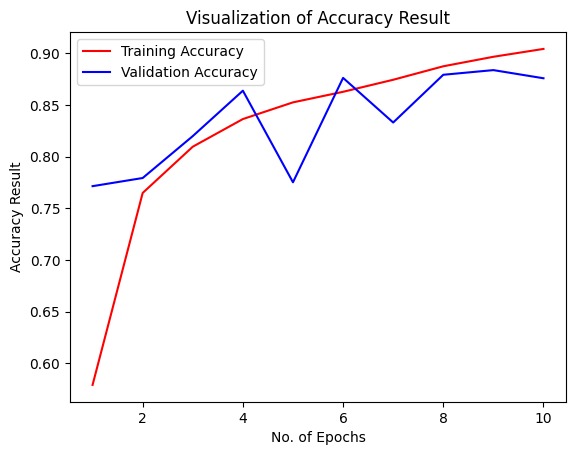

In [47]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

In [48]:
# Some other metrics for model evaluation

In [49]:
class_name = validation_set.class_names
class_name

['Corn___Common_Rust',
 'Corn___Gray_Leaf_Spot',
 'Corn___Healthy',
 'Corn___Northern_Leaf_Blight',
 'Potato___Early_Blight',
 'Potato___Healthy',
 'Potato___Late_Blight',
 'Rice___Brown_Spot',
 'Rice___Healthy',
 'Rice___Leaf_Blast',
 'Rice___Neck_Blast',
 'Sugarcane_Bacterial Blight',
 'Sugarcane_Healthy',
 'Sugarcane_Red Rot',
 'Wheat___Brown_Rust',
 'Wheat___Healthy',
 'Wheat___Yellow_Rust']

In [51]:
print(os.listdir("/content"))


['.config', 'top-agriculture-crop-disease.zip', 'trained_model.keras', 'Crop Diseases', 'training_hist.json', 'sample_data']


In [53]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/Crop Diseases',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)
model.evaluate(validation_set)


Found 13324 files belonging to 17 classes.
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 239ms/step - accuracy: 0.8671 - loss: 0.3544


[0.32252129912376404, 0.8757507801055908]

In [54]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

417/417 ━━━━━━━━━━━━━━━━━━━━ 99s 236ms/step


(array([[1.00000000e+00, 1.98467385e-24, 1.72498146e-36, ...,
         1.26015533e-31, 8.41530379e-35, 1.01831496e-32],
        [1.00000000e+00, 7.98244397e-21, 1.62655477e-25, ...,
         4.85416190e-25, 5.00062263e-29, 3.16165159e-26],
        [1.00000000e+00, 1.29254898e-27, 6.70605468e-31, ...,
         7.56784388e-27, 8.81438642e-35, 5.61618024e-28],
        ...,
        [1.07759661e-06, 3.80475511e-04, 2.40560917e-06, ...,
         9.66951028e-02, 3.17098011e-06, 9.02873993e-01],
        [8.21137219e-05, 1.67723317e-02, 5.50232304e-04, ...,
         4.57245797e-01, 1.23276230e-04, 5.22048175e-01],
        [1.02609498e-07, 1.64676828e-06, 5.00343980e-08, ...,
         3.23760381e-04, 8.86517284e-07, 9.99671400e-01]], dtype=float32),
 (13324, 17))

In [55]:
predicted_categories = tf.argmax(y_pred,axis=1)

In [56]:
predicted_categories

<tf.Tensor: shape=(13324,), dtype=int64, numpy=array([ 0,  0,  0, ..., 16, 16, 16])>

In [58]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(13324, 17), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [59]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(13324,), dtype=int64, numpy=array([ 0,  0,  0, ..., 16, 16, 16])>

In [60]:
pip install scikit-learn


In [61]:
from sklearn.metrics import classification_report,confusion_matrix

In [62]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                             precision    recall  f1-score   support

         Corn___Common_Rust       1.00      1.00      1.00      1192
      Corn___Gray_Leaf_Spot       0.81      0.94      0.87       513
             Corn___Healthy       1.00      1.00      1.00      1162
Corn___Northern_Leaf_Blight       0.98      0.85      0.91       985
      Potato___Early_Blight       0.99      0.99      0.99      1000
           Potato___Healthy       0.98      0.96      0.97       152
       Potato___Late_Blight       0.99      0.98      0.98      1000
          Rice___Brown_Spot       0.77      0.73      0.75       613
             Rice___Healthy       0.73      0.93      0.82      1488
          Rice___Leaf_Blast       0.77      0.46      0.58       977
          Rice___Neck_Blast       1.00      1.00      1.00      1000
 Sugarcane_Bacterial Blight       0.88      0.79      0.83       100
          Sugarcane_Healthy       0.96      0.94      0.95       100
          Sugarcane_Red Rot      

In [63]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[1189,    1,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    1,    0,    1],
       [   0,  484,    1,   14,    0,    0,    0,    0,    0,    0,    0,
           1,    0,    0,   11,    0,    2],
       [   0,    0, 1159,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    1,    0,    0,    0,    2],
       [   1,  110,    1,  836,    1,    0,    0,    0,    0,    0,    0,
           0,    0,    1,   35,    0,    0],
       [   1,    0,    0,    0,  992,    0,    7,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,  146,    6,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0],
       [   0,    2,    0,    1,   10,    3,  982,    0,    0,    0,    0,
           0,    0,    0,    2,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,  445,   96,   72,    0,
           0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0

In [64]:
### Confusion Matrix Visualization

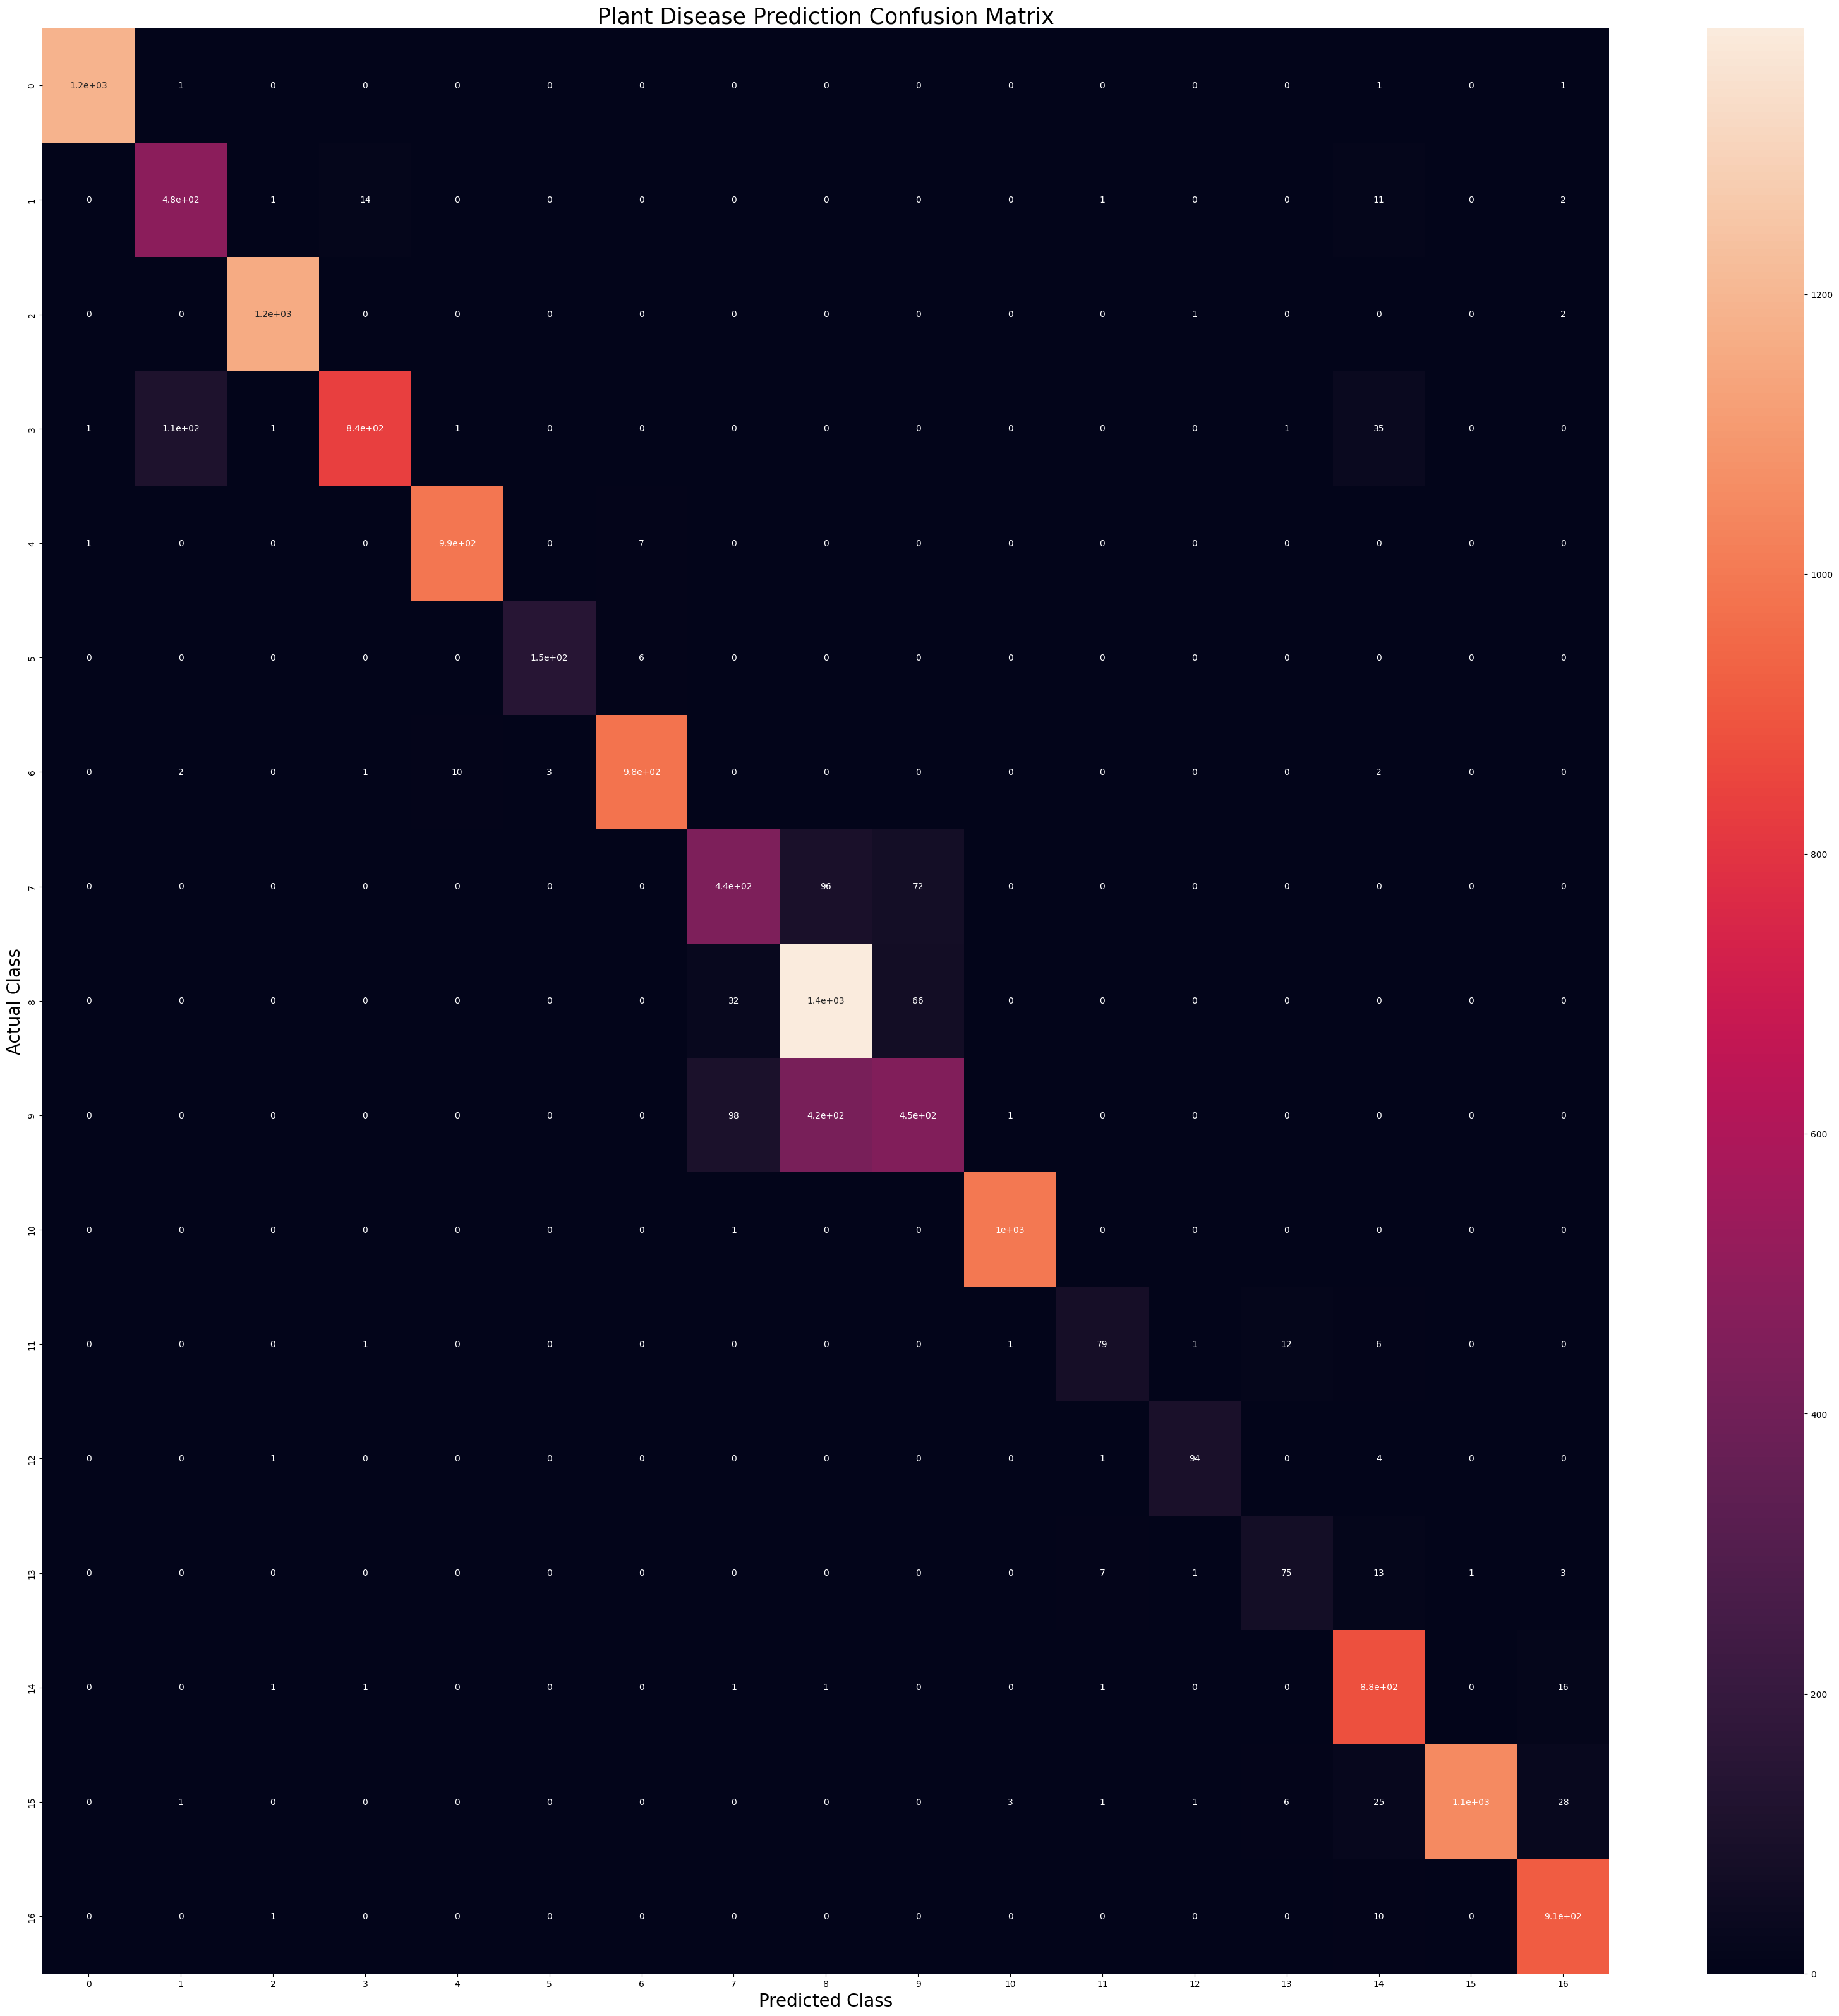

In [65]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()

In [67]:
# Save in native Keras format
model.save("crop_model.keras")


In [68]:
from google.colab import files
files.download("crop_model.keras")  # or crop_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>